# Decision Tree Regressor

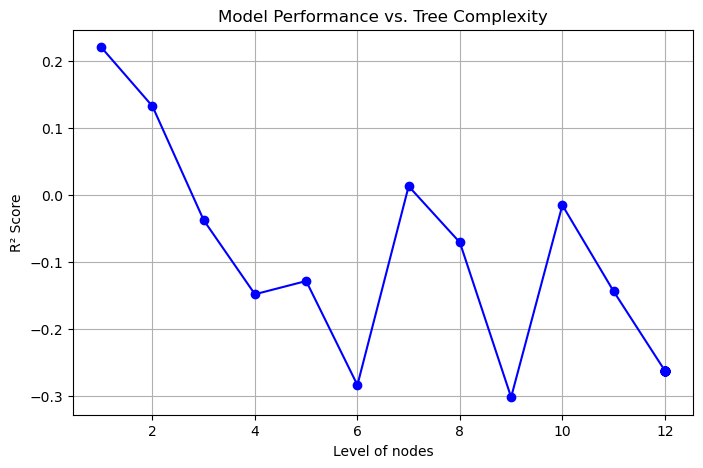

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# File paths
input_file_path = "D:\\final_year_project\\final_export\\csv\\new\\training_parameters_postprocessing_new.csv"

# Load dataset
df = pd.read_csv(input_file_path)

# Define features (X) and target (y)
X = df.iloc[:, :-1]  # First 20 columns as features
y = df.iloc[:, -1]   # Last column as target (wear rate)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lists to store results
r2_scores = []
depth_count = []
depths = range(1, 50)  # Testing max_depth from 1 to 10

for depth in depths:
    # Train Decision Tree Regressor
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    # Predict and calculate R2 score
    y_pred = tree.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    # Store results
    r2_scores.append(r2)
    depth_count.append(tree.get_depth())


#     print(f"\nTree with max_depth={depth}:")
#     print(export_text(tree, feature_names=list(X.columns)))

    
#     plt.figure(figsize=(12, 6))
#     plot_tree(tree, feature_names=list(X.columns), filled=True, rounded=True)
#     plt.title(f"Decision Tree (max_depth={depth})")
#     plt.show()

# Plot R2 Score vs Number of Nodes
plt.figure(figsize=(8, 5))
plt.plot(depth_count, r2_scores, marker='o', linestyle='-', color='b')
plt.xlabel("Level of nodes")
plt.ylabel("R² Score")
plt.title("Model Performance vs. Tree Complexity")
plt.grid()
plt.show()
